**Script: First check of the mux2501_r2b7 run (5yrs)**
- Author: Muxin Hu (muxin.hu@mpimet.mpg.de)
- Date created: 07/11/2025
- Late modified: 07/11/2025 

**Paths**
- the pyic package is downloaded and installed in the directory: `/home/m/m301254/Download/pyicon`
- the data is stored in `/work/mh0033/m301254/proj_surfwave/icon-2025-11_1/icon-mpim/experiments/mux2501_r2b7`


In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import pyicon as pyic
import cartopy.crs as ccrs
# from netCDF4 import Dataset
# import sys

----Start loading pyicon.
Loading default parameters from /home/m/m301254/Download/pyicon/pyicon/params_default.json.
----Start loading pyicon.
----Pyicon was loaded successfully.
----Pyicon was loaded successfully.


# Analysis on `mux2501_r2b7` test run
- **Simulation period**: 5 years; 2000-01-01T-000000Z to 2005-01-01T-000000Z
- **running script**: `/work/mh0033/m301254/proj_surfwave/icon-2025-11_1/icon-mpim/run/exp.mux2501_r2b7.run`

In [ ]:
# Names and paths
run='mux2501_r2b7'
gname='r2b7_oce_r0005'
lev='L72'

# directory paths
path_data = f'/work/mh0033/m301254/proj_surfwave/icon-2025-11_1/icon-mpim/experiments/{run}'
# path_grid = f'/home/m/m301254/pyicon_data/grids/{gname}'
path_grid = f'/work/mh0033/m301254/icon/grids/{gname}'
path_ckdtree= f'{path_grid}/ckdtree'                             # useful for large data interpolation

# file paths
fpath_fx = f'{path_grid}/{gname}_{lev}_fx.nc'
fpath_tgrid = f'{path_grid}/{gname}_tgrid.nc'
res = 'res0.30' # choose resolution for interplation between 1.00, 0.30, 0.10, 0.02
fpath_ckdtree= f'{path_ckdtree}/rectgrids/{gname}_{res}_180W-180E_90S-90N.nc'


In [16]:
fpath_tgrid

'/work/mh0033/m301254/icon/grids/r2b7_oce_r0005/r2b7_oce_r0005_tgrid.nc'

In [5]:
# specify dataset
ds_3d  = xr.open_dataset(f'{path_data}/mux2501_r2b7_P1Y_3d_20000101T000000Z.nc')
ds_tke = xr.open_dataset(f'{path_data}/mux2501_r2b7_P1Y_tke_20000101T000000Z.nc')
ds_2d = xr.open_dataset(f'{path_data}/mux2501_r2b7_P1M_2d_20000101T000000Z.nc')

## Upper-most potential T, 5-years winter mean

In [8]:
# select target variables: to and 
# to_3d = ds_3d['to']
to_2d = ds_2d['to']

In [25]:
# check 5-years winter mean
to_2d = to_2d.where(to_2d != 0.)
to_2d_JFM_mean = to_2d.isel(depth=0).sel(time=to_2d.time.dt.month.isin([1,2,3])).mean(dim='time')
to_2d_JJA_mean = to_2d.isel(depth=0).sel(time=to_2d.time.dt.month.isin([6,7,8])).mean(dim='time')

### plot on the original triangular grid
Specify region and derive triangulatino object using pyic.triangulation
- **pyic.triangulation**: builds a Matplotlib Triangulation object (a triangular mesh) from the ICON unstructured grid
- default: def triangulation(ds_tgrid, lon_reg=None, lat_reg=None,
                  do_mask_big_triangles=True, only_lon=True,
                  shift_to_zero_dateline=False):
    - ds_grid: ICON's t-grid dataset, contains vertex and cell geometry
    - lon_reg, lat_reg: optional region bounds
    - do_mask_big_triangles: Whether to mast abnormallt large triangles (occurs near boundaries and poles)
    - only_lon: internal flag controlling how big triangles are detected
    - shift_to_zero_dateline: if True, moves all longitudes from [-180,180] to [0,360]


In [26]:
# for the global map
lon_reg = [-60, 5]
lat_reg = [30, 75]
ds_tg = xr.open_dataset(fpath_tgrid)
ind_reg, Tri_reg = pyic.triangulation(ds_tg, lon_reg=lon_reg, lat_reg=lat_reg)
ind_glo, Tri_glo = pyic.triangulation(ds_tg)

to_2d_JFM_mean_reg = to_2d_JFM_mean.isel(ncells=ind_reg)
to_2d_JJA_mean_reg = to_2d_JJA_mean.isel(ncells=ind_reg)


Text(0.5, 1.0, '$^o$C')

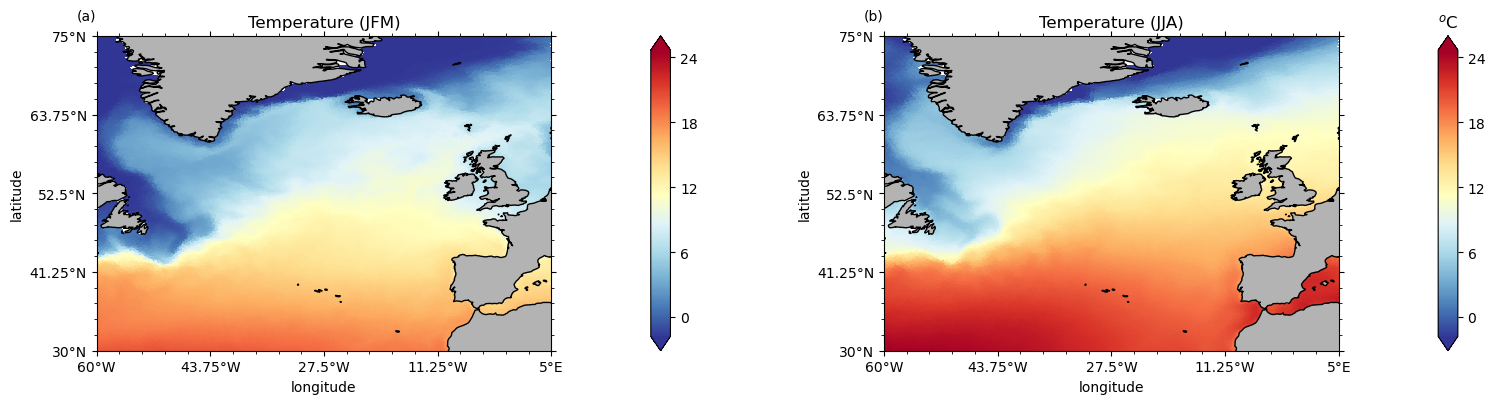

In [32]:
# plot for comparison to JFM and JJA means
projection = ccrs.PlateCarree()

vmin = min(to_2d_JFM_mean_reg.min(), to_2d_JJA_mean_reg.min())
vmax = max(to_2d_JFM_mean_reg.max(), to_2d_JJA_mean_reg.max())

# --- with one colorbar for all axes
hca, hcb = pyic.arrange_axes(
    nx=2, ny=1,              # 2 plots horizontally
    plot_cb=True,            # include colorbar
    asp=0.5,                 # aspect ratio
    fig_size_fac=2.0,
    projection=projection,

)
ii = -1

# JFM
ii += 1; ax = hca[ii]; cax = hcb[ii]
pyic.shade(
    Tri_reg, to_2d_JFM_mean_reg,
    ax=ax, cax=cax,
    clim=(vmin, vmax),
)
ax.set_title('Temperature (JFM)')
ax.set_xlabel('longitude')
ax.set_ylabel('latitude')
pyic.plot_settings(ax, xlim=lon_reg, ylim=lat_reg)

# JJA
ii += 1; ax = hca[ii]; cax = hcb[ii]
pyic.shade(
    Tri_reg, to_2d_JJA_mean_reg,
    ax=ax, cax=cax,          # share colorbar
    clim=(vmin, vmax),
)
ax.set_title('Temperature (JJA)')
ax.set_xlabel('longitude')
ax.set_ylabel('latitude')
pyic.plot_settings(ax, xlim=lon_reg, ylim=lat_reg)

cax.set_title('$^o$C')


## TKE profile at 26N 30W

In [39]:
ds_tke

<xarray.Dataset> Size: 22GB
Dimensions:       (ncells: 935760, vertices: 3, time: 5, depth: 73)
Coordinates:
  * time          (time) datetime64[ns] 40B 2000-01-01 2001-01-01 ... 2004-01-01
  * depth         (depth) float64 584B 0.0 2.0 4.2 ... 5.681e+03 5.951e+03
    clon          (ncells) float64 7MB 1.274 1.282 1.274 ... 1.337 1.33 1.333
    clat          (ncells) float64 7MB 1.259 1.257 1.261 ... -0.7932 -0.7888
Dimensions without coordinates: ncells, vertices
Data variables: (12/20)
    clon_bnds     (ncells, vertices) float64 22MB ...
    clat_bnds     (ncells, vertices) float64 22MB ...
    tke           (time, depth, ncells) float32 1GB ...
    vmix_dummy_1  (time, depth, ncells) float32 1GB ...
    vmix_dummy_2  (time, depth, ncells) float32 1GB ...
    vmix_dummy_3  (time, depth, ncells) float32 1GB ...
    ...            ...
    tke_Lmix      (time, depth, ncells) float32 1GB ...
    tke_Pr        (time, depth, ncells) float32 1GB ...
    tke_plc       (time, depth, ncells) float32 1GB ...
    wlc           (time, depth, ncells) float32 1GB ...
    hlc           (time, ncells) float32 19MB ...
    u_stokes      (time, ncells) float32 19MB ...
Attributes:
    CDI:                  Climate Data Interface version 2.5.2.1 (https://mpi...
    Conventions:          CF-1.6
    number_of_grid_used:  42
    uuidOfHGrid:          5797407c-1c47-11ea-ae87-f7ba6feb63f1
    institution:          Max Planck Institute for Meteorology/Deutscher Wett...
    title:                ICON simulation
    source:               version: 2025.10; revision: unknown; URL: unknown
    history:              /work/mh0033/m301254/proj_surfwave/icon-2025-11_1/i...
    references:           see MPIM/DWD publications
    comment:              Muxin Hu (m301254) on l30181 (Linux 4.18.0-553.74.1...

### Find the the indices for targeted location

In [35]:
# select the target location
clon, clat = ds_tke.clon.data*180./np.pi, ds_tke.clat.data*180./np.pi
ip26N30W = np.argmin((clat-26)**2+(clon+30)**2)
clon[ip26N30W], clat[ip26N30W]

(np.float64(-29.957548039144008), np.float64(26.06989322637232))

### Calculate the mean

In [ ]:
# find the 5-yrs winter mean profile for each tendency and plot
# list of variables
tke_tend_vars = ['tke_Tbpr',  # buoyancy production
                 'tke_Tspr',  # shear production
                 'tke_Tdif',  # diffusive transport
                 'tke_Tdis',  # dissipation
                 'tke_Twin',  # wind forcing
                 'tke_Tiwf',  # internal wave forcing
                 'tke_Tbck',  # background mixing
                 'tke_Ttot',  # total tendency
]




# ds_tke_JFM_mean = ds_tke.sel(time=ds_tke.time.dt.month.isin([1,2,3])).mean(dim='time')
# ds_tke_JJA_mean = ds_tke.sel(time=ds_tke.time.dt.month.isin([6,7,8])).mean(dim='time')